<a href="https://colab.research.google.com/github/purduelamm/purdue_me597_iiot/blob/main/lab/lab6/L6_Colab2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 6.2 Database & Visualization - Python MySQL Hands-on Activities

## 2.1 Python Programming Using PyMySQL


The example sample code ([lab6_sample.py](https://github.com/purduelamm/purdue_me597_iiot/blob/main/lab/lab6/lab6_sample.py?raw=true)) is on Github repo and as below. This example is generating 3 random values and then executing INSERT statements to store the values on the MySQL database. The sampling period is 3 seconds and total collection time is 60 seconds. Please go through the code and comments on each line to understand program logic. Please note that you need to modify the 'USER', 'PASSWORD', and 'TABLE' lines to run the sample script.

---

**<img src="https://github.com/purduelamm/purdue_me597_iiot/blob/main/lab/img/icon_Python.png?raw=tru" width="20">Python - Python3 ([lab6_sample.py](https://github.com/purduelamm/purdue_me597_iiot/blob/main/lab/lab6/lab6_sample.py?raw=true))**

```
import datetime
import time
import random
import pymysql.cursors

## Credential
HOST = 'mepotrb16.ecn.purdue.edu' # MySQL server host DNS
PORT = 3306 # MySQL server port number
USER = 'yourname' # MySQL account name
PASSWORD = 'password' # Password of the account
DB = 'ME597Spring24' # DB name (you should double check your database name)
TABLE = 'yourname_lab6' # table name
## Credential

sensor = 'sensor3' # sensor name
measurement1 = 'acceleration1' # measurement name 1
measurement2 = 'acceleration2' # measurement name 2
measurement3 = 'acceleration3' # measurement name 3

connection = pymysql.connect(host=HOST, user=USER, password=PASSWORD, db=DB, port=PORT) # make a connection to MySQL server
cursor = connection.cursor() # Open cursur to execute SQL query

duration = 60 # collection time in second unit
start_time = time.time() # get current time

while time.time() - start_time < duration:
    value1 = str(random.uniform(0,2)) # random value for measurement1
    value2 = str(random.uniform(-2,0)) # random value for measurement2
    value3 = str(random.uniform(9.7,9.9)) # random value for measurement3
    timestamp = datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S') # get datetime as MySQL timestamp format
    
    print(timestamp)
    print("{}={}".format(measurement1,value1)) # value1
    print("{}={}".format(measurement2,value2)) # value2
    print("{}={}".format(measurement3,value3)) # value2
    
    query1 = "INSERT INTO "+TABLE+" (timestamp,sensor,measurement,value) VALUE('"+timestamp+"','"+sensor+"','"+measurement1+"','"+value1+"');" #SQL query1 for value1
    query2 = "INSERT INTO "+TABLE+" (timestamp,sensor,measurement,value) VALUE('"+timestamp+"','"+sensor+"','"+measurement2+"','"+value2+"');" #SQL query2 for value2
    query3 = "INSERT INTO "+TABLE+" (timestamp,sensor,measurement,value) VALUE('"+timestamp+"','"+sensor+"','"+measurement3+"','"+value3+"');" #SQL query3 for value3
    
    cursor.execute(query1) # execute query 1
    cursor.execute(query2) # execute query 2
    cursor.execute(query3) # execute query 3
    connection.commit() # commit all SQL queries
    
    print("==INSERT QUERIES DONE==\n")
    
    time.sleep(3) # wait for 3 seconds

connection.close() # gently close connection
print("==Program DONE==")

```

---

After run the sample code, you can see the stored data on ‘MySQL Workbench’ on laptop as Figure 5.

<img src="https://github.com/purduelamm/purdue_me597_iiot/blob/main/lab/img_S24_update/lab6_fig5.png?raw=true" width="70%">

*Figure 5 MySQL Workbench result grid after running sample script*

### Task 2.1

Run the sample code on Raspberry Pi. Capture the result grid on MySQL workbench as Figure 5 and attach it to the report.

---

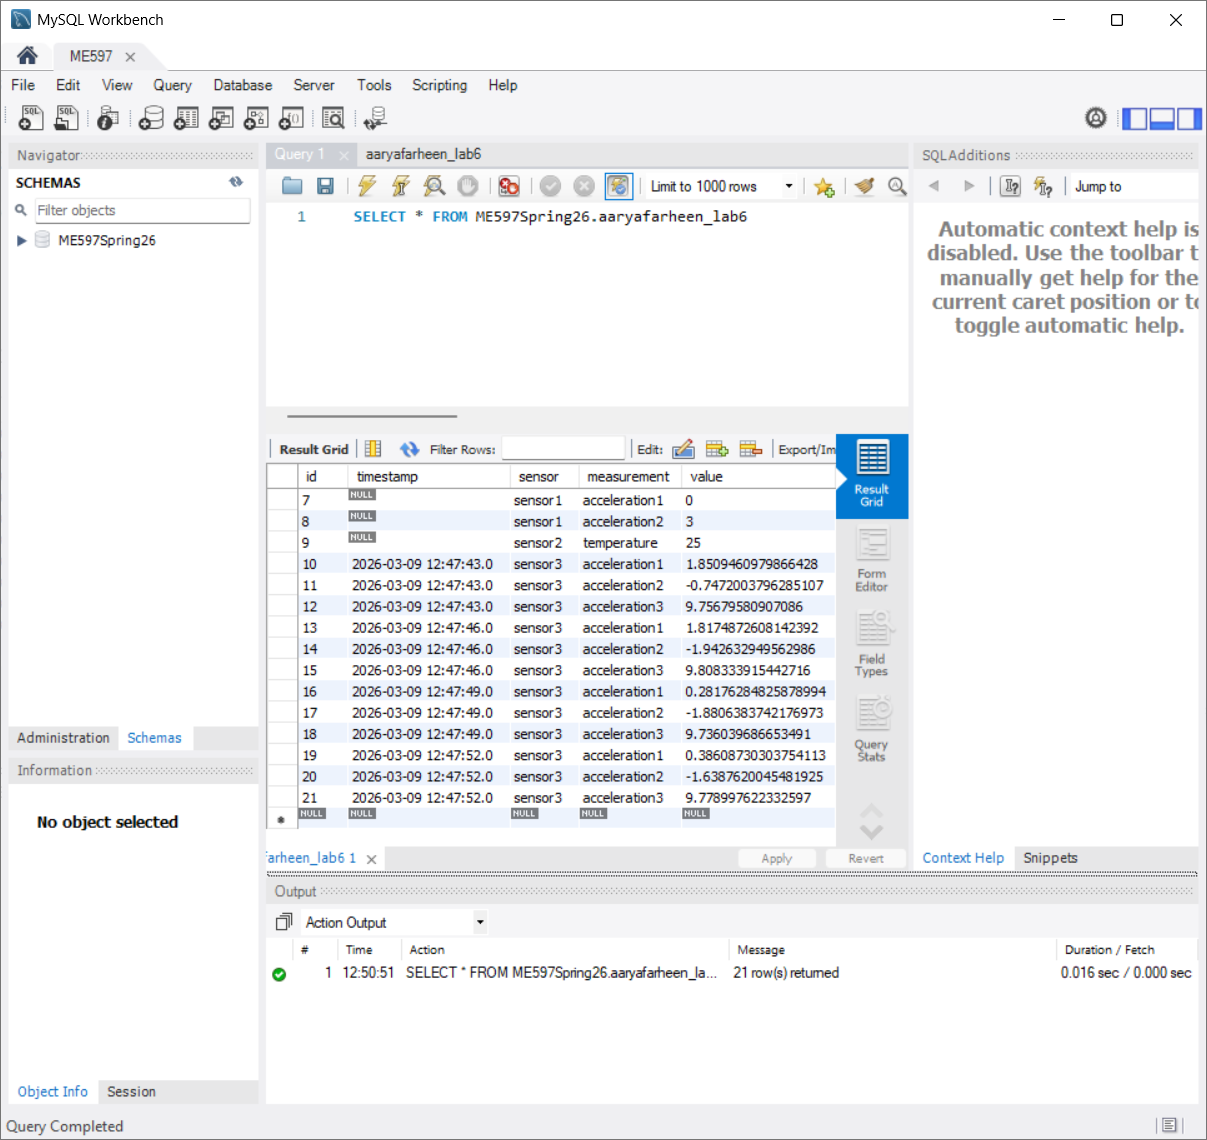

---


Now, let’s store the measured data to MySQL database from the sensors (DS18B20 and ADXL345). The schematic of data collection is shown in Figure 6.

<img src="https://github.com/purduelamm/purdue_me597_iiot/blob/main/lab/img_S25_update/lab6_fig1.png?raw=true" width="70%">

*Figure 6 Schematic for Task 2.2*

### Task 2.2

1. Modify the given sample code (above) to store sensor data (acceleration of each axis from ADXL345, temperature from DS18B20, and humidity from virtual sensor) into the MySQL database you created. The data collection specifications are below:

  a.	Total collection time is 120 seconds.

  b.	Sampling period, Ts, is 3 seconds.

  c.	Sensor name (sensor column) of ADXL345 is “ADXL345”.

  d.	Sensor name (sensor column) of DS18B20 is “DS18B20”.

  e.  Sensor name (sensor column) of Virtual sensor is “Virtual”.

  f.	Measurements (measurement column) of ADXL345 are “Xacc”, “Yacc”, “Zacc”.

  g.	Measurements (measurement column) of ADXL345 are “Temp”, “Humd”.

  h.	Values (value column) of ADXL345 are measured data in unit of m/s2.

  i.	Values (value column) of DS18B20 are measured data in °C.
  
  j.  Values (value column) of Virtual sensor are measured data in RH%.

  **Hint: To measure data, refer to the sample codes (**[lab5_ADXL345_sample.py](https://github.com/purduelamm/purdue_me597_iiot/blob/main/lab/lab5/lab5_sample/lab5_ADXL345_sample.py?raw=true) and [lab5_DS18B20_sample.py](https://github.com/purduelamm/purdue_me597_iiot/blob/main/lab/lab5/lab5_sample/lab5_DS18B20_sample.py?raw=true)
  **) in the previous lab.**

2.	Run the modified script.
3.	Check the stored data in MySQL database using ‘MySQL Workbench’.


### Task 2.3

1.	Capture the result grid shown in Figure 5 and attach it to the report.

  ---
  
  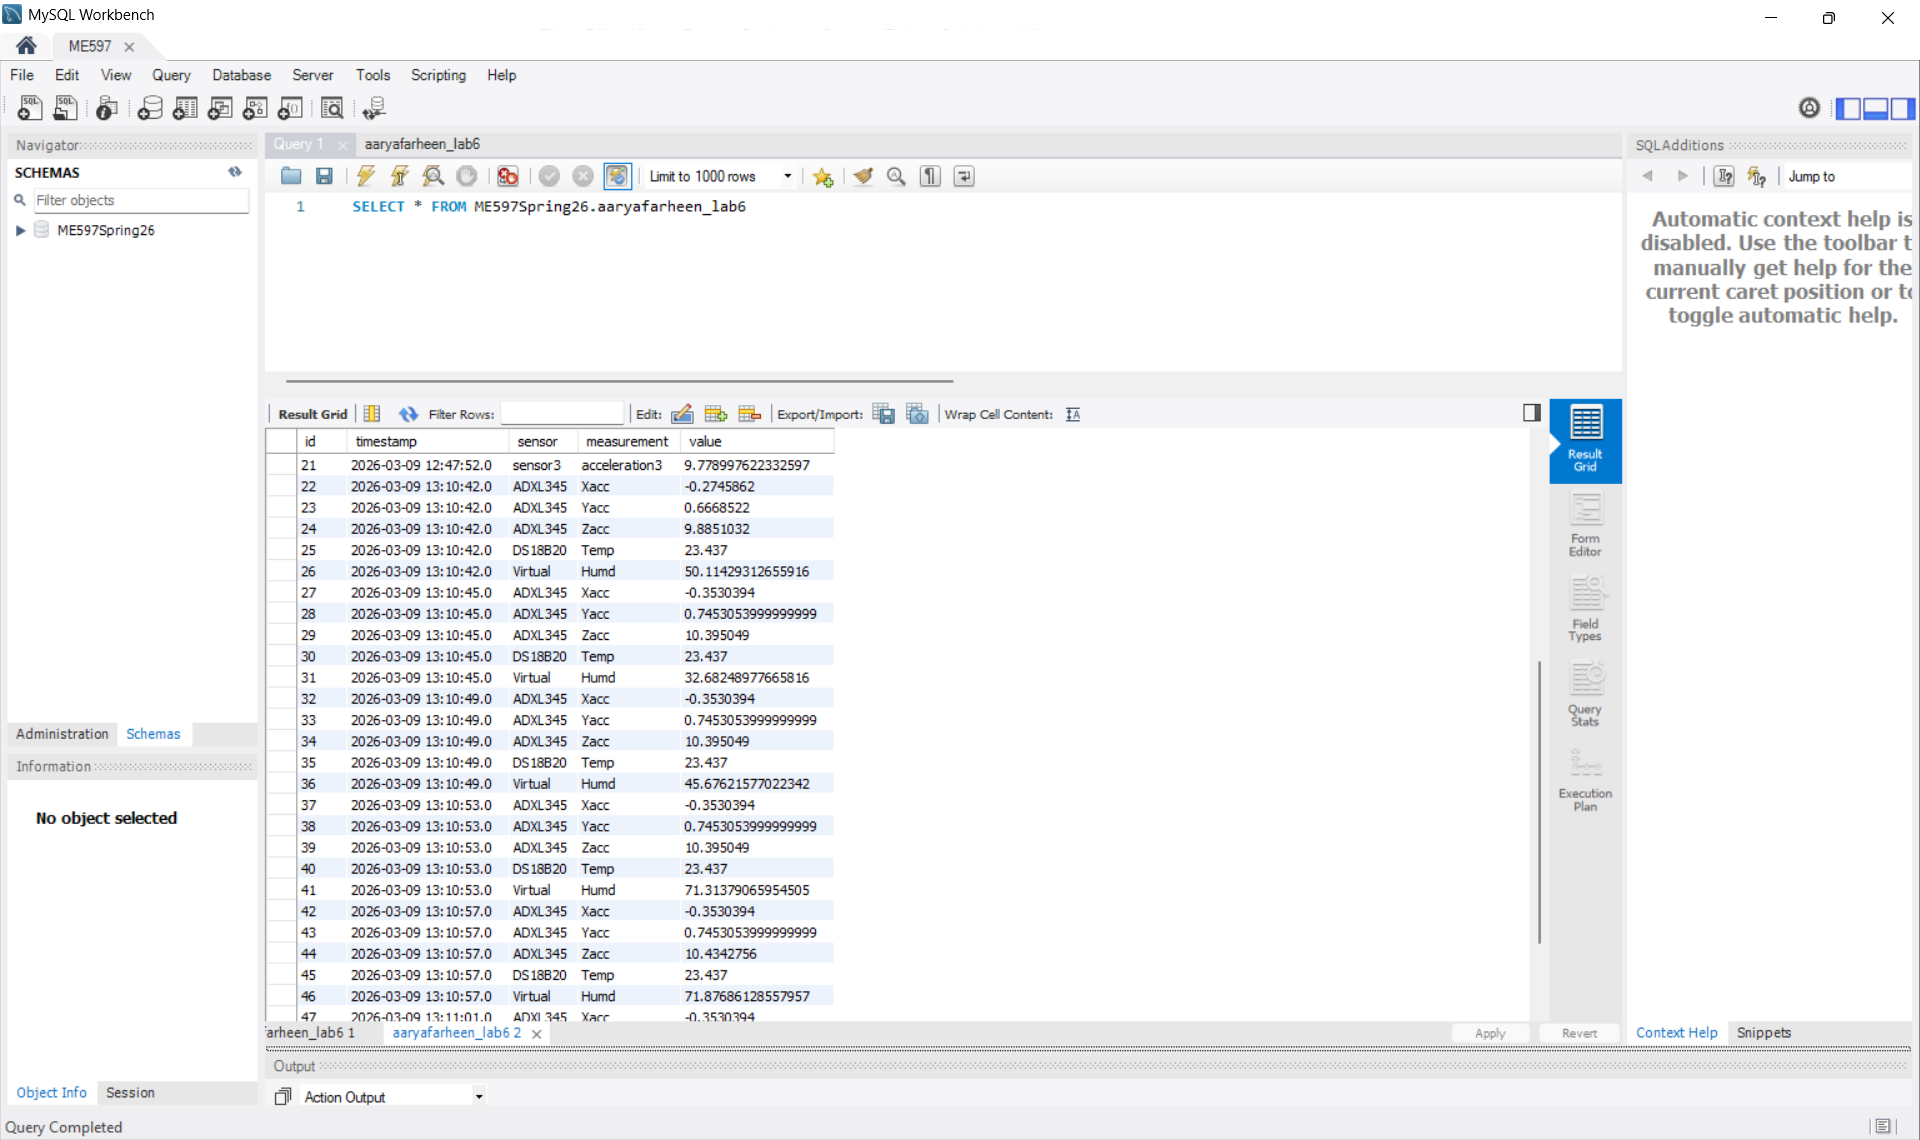
  
  ---

2.	Place the modified code below

In [ ]:
# Paste your code below.
#
import datetime
import time
import random
import pymysql.cursors
import board
import busio
import adafruit_adxl34x
import os
import glob

# ---------------- MySQL Credentials ----------------
HOST = 'mepotrb16.ecn.purdue.edu'
PORT = 3306
USER = 'aaryafarheen'
PASSWORD = 'Abcd1234!'
DB = 'ME597Spring26'
TABLE = 'aaryafarheen_lab6'

# ---------------- Sensor Names ----------------
sensor_ADXL = "ADXL345"
sensor_DS = "DS18B20"
sensor_virtual = "Virtual"

# ---------------- Measurements ----------------
m_x = "Xacc"
m_y = "Yacc"
m_z = "Zacc"
m_temp = "Temp"
m_humd = "Humd"

# ---------------- MySQL Connection ----------------
connection = pymysql.connect(host=HOST, user=USER, password=PASSWORD, db=DB, port=PORT)
cursor = connection.cursor()

# ---------------- ADXL345 Setup ----------------
i2c = busio.I2C(board.SCL, board.SDA)
acc = adafruit_adxl34x.ADXL345(i2c)

# ---------------- DS18B20 Setup ----------------
os.system('modprobe w1-gpio')
os.system('modprobe w1-therm')

base_dir = '/sys/bus/w1/devices/'
device_folder = glob.glob(base_dir + '28*')[0]
device_file = device_folder + '/w1_slave'

def read_temp_raw():
    f = open(device_file, 'r')
    lines = f.readlines()
    f.close()
    return lines

def read_temp():
    lines = read_temp_raw()
    while lines[0].strip()[-3:] != 'YES':
        time.sleep(0.2)
        lines = read_temp_raw()
    equals_pos = lines[1].find('t=')
    if equals_pos != -1:
        temp_string = lines[1][equals_pos+2:]
        temp_c = float(temp_string) / 1000.0
        return temp_c

# ---------------- Data Collection Settings ----------------
duration = 120
Ts = 3
start_time = time.time()

while time.time() - start_time < duration:

    timestamp = datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S')

    # -------- ADXL345 --------
    x_acc, y_acc, z_acc = acc.acceleration

    # -------- DS18B20 --------
    temperature = read_temp()

    # -------- Virtual Humidity --------
    humidity = random.uniform(30, 80)

    print(timestamp)
    print(f"Xacc={x_acc:.4f}")
    print(f"Yacc={y_acc:.4f}")
    print(f"Zacc={z_acc:.4f}")
    print(f"Temp={temperature:.2f}")
    print(f"Humd={humidity:.2f}")

    # -------- SQL Queries --------
    query1 = "INSERT INTO "+TABLE+" (timestamp,sensor,measurement,value) VALUE('"+timestamp+"','"+sensor_ADXL+"','"+m_x+"','"+str(x_acc)+"');"
    query2 = "INSERT INTO "+TABLE+" (timestamp,sensor,measurement,value) VALUE('"+timestamp+"','"+sensor_ADXL+"','"+m_y+"','"+str(y_acc)+"');"
    query3 = "INSERT INTO "+TABLE+" (timestamp,sensor,measurement,value) VALUE('"+timestamp+"','"+sensor_ADXL+"','"+m_z+"','"+str(z_acc)+"');"

    query4 = "INSERT INTO "+TABLE+" (timestamp,sensor,measurement,value) VALUE('"+timestamp+"','"+sensor_DS+"','"+m_temp+"','"+str(temperature)+"');"

    query5 = "INSERT INTO "+TABLE+" (timestamp,sensor,measurement,value) VALUE('"+timestamp+"','"+sensor_virtual+"','"+m_humd+"','"+str(humidity)+"');"

    cursor.execute(query1)
    cursor.execute(query2)
    cursor.execute(query3)
    cursor.execute(query4)
    cursor.execute(query5)

    connection.commit()

    print("==INSERT QUERIES DONE==\n")

    time.sleep(Ts)

connection.close()

print("==Program DONE==")


#

## Lab6 Summary and Deliverables

Answer the following questions for your achievements




### Q1. Please summarize Lab6.

---

Lab 6 focused on learning how to store and manage sensor data using a MySQL database and Python. In Part 1, the objective was to install and configure MySQL tools such as MySQL Workbench and connect to the remote MySQL server provided for the course. Basic database operations were studied, including creating tables, inserting records, and retrieving data using SQL queries. This part helped in understanding how databases are structured and how data can be stored and accessed efficiently.

In Part 2, the lab involved collecting real-time sensor data and storing it in the MySQL database using Python. Data was collected from multiple sources, including the ADXL345 accelerometer (X, Y, and Z acceleration), the DS18B20 temperature sensor, and a virtual humidity sensor. A Python script was developed to read sensor values at a fixed sampling period of 3 seconds for a total duration of 120 seconds. The collected data, along with timestamps, sensor names, and measurement types, was inserted into the database table using SQL insert queries. Finally, the stored data was verified using MySQL Workbench to ensure that the information was correctly recorded. This lab demonstrated the integration of sensors, Python programming, and database management for real-time data acquisition and storage.

---


### Q2. What skills did you have to develop to accomplish this project?

---

* Understanding basic SQL operations such as creating tables, inserting data, and retrieving records from a MySQL database.

* Developing Python programming skills to connect to the database and automate data insertion using scripts.

* Learning how to interface sensors with Raspberry Pi and collect real-time data from devices like ADXL345 and DS18B20.

---

### Q3. What aspects of this project were the most beneficial for your learning?

---

* Gaining hands-on experience with integrating hardware sensors (ADXL345 and DS18B20) with software.

* Learning how to store and manage real-time data in a MySQL database efficiently.

* Understanding the end-to-end workflow of data acquisition, processing, and storage, which is essential for IoT and automation projects.

---

### Q4. What challenges did you encounter in completing the project?

---

* The ADXL345 sensor was not detected initially due to I2C configuration or wiring issues.

* Ensuring the correct timing for data collection (sampling every 3 seconds) without missing or overlapping readings.

---

### Q5. How did you overcome the challenges or remedy the problems encountered?

---

* For the ADXL345 detection issue, I checked and enabled I2C on the Raspberry Pi, verified the wiring and power connections, and used i2cdetect -y 1 to confirm the sensor address.

* To maintain correct sampling, I used time.sleep(Ts) and controlled the loop duration to ensure readings were taken precisely every 3 seconds.

---

<br></br>

Get back to [Lab Index Page](https://colab.research.google.com/github/purduelamm/purdue_me597_iiot/blob/main/index.ipynb)